# Практическая 11-12 (Саттаров Булат Рамилевич ЭФМО-01-25)

## Задание

1. Произвести методом k-means кластеризацию вин. Датасет взять из третьей работы. Произвести разные варианты инициализации центров. Сравнить результат.
2. Выбрать черно-белое и цветное изображение. Сжать изображения с помощью метода k-means.
3. Применить KMeans для кластеризации текстов из набора `20_newsgroups` на 20 кластеров. Оценить, насколько точно кластеризация совпадает с исходной классификацией датасета.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import zipfile
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    confusion_matrix
)
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 1. Кластеризация вин методом KMeans

Загрузим датасет `winequality-red.csv` из третьей практической работы. Для оценки качества кластеризации сформируем бинарную разметку так же, как в третьей работе: хорошее вино — `quality >= 7`, остальные вина — некачественные.

In [3]:
wine = pd.read_csv('winequality-red.csv')
if wine.shape[1] == 1:
    wine = pd.read_csv('winequality-red.csv', sep=';')

wine['target'] = np.where(wine['quality'] >= 7, 1, 0)
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,target
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [4]:
print('Размер данных:', wine.shape)
print(wine['target'].value_counts().rename(index={0: 'Некачественное', 1: 'Качественное'}))

Размер данных: (1599, 13)
target
Некачественное    1382
Качественное       217
Name: count, dtype: int64


In [5]:
X_wine = wine.drop(columns=['quality', 'target'])
y_wine = wine['target'].values

scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

## Разные варианты инициализации центров

Сравним три варианта:

* `k-means++` — стандартная умная инициализация;
* `random` — случайный выбор начальных центров;
* `manual` — центры заданы вручную: средний объект класса 0 и средний объект класса 1. Этот вариант используется только для сравнения, так как в реальной кластеризации истинных классов обычно нет.

In [6]:
manual_centers = np.vstack([
    X_wine_scaled[y_wine == 0].mean(axis=0),
    X_wine_scaled[y_wine == 1].mean(axis=0)
])

configs = [
    {'name': 'k-means++', 'init': 'k-means++', 'n_init': 20},
    {'name': 'random', 'init': 'random', 'n_init': 20},
    {'name': 'manual centers', 'init': manual_centers, 'n_init': 1}
]

wine_results = []
wine_labels = {}

for cfg in configs:
    km = KMeans(n_clusters=2, init=cfg['init'], n_init=cfg['n_init'], random_state=SEED)
    labels = km.fit_predict(X_wine_scaled)
    wine_labels[cfg['name']] = labels

    wine_results.append({
        'Инициализация': cfg['name'],
        'Inertia': km.inertia_,
        'ARI': adjusted_rand_score(y_wine, labels),
        'AMI': adjusted_mutual_info_score(y_wine, labels),
        'Homogeneity': homogeneity_score(y_wine, labels),
        'Completeness': completeness_score(y_wine, labels),
        'V-measure': v_measure_score(y_wine, labels),
        'Silhouette': silhouette_score(X_wine_scaled, labels)
    })

wine_results_df = pd.DataFrame(wine_results)
wine_results_df

,Инициализация,Inertia,ARI,AMI,Homogeneity,Completeness,V-measure,Silhouette
0,k-means++,14330.119811,0.084254,0.047923,0.064443,0.038867,0.048489,0.213730
1,random,14330.142460,0.085380,0.048418,0.065059,0.039278,0.048983,0.213942
2,manual centers,14331.307255,0.072681,0.048778,0.066370,0.039260,0.049336,0.207677


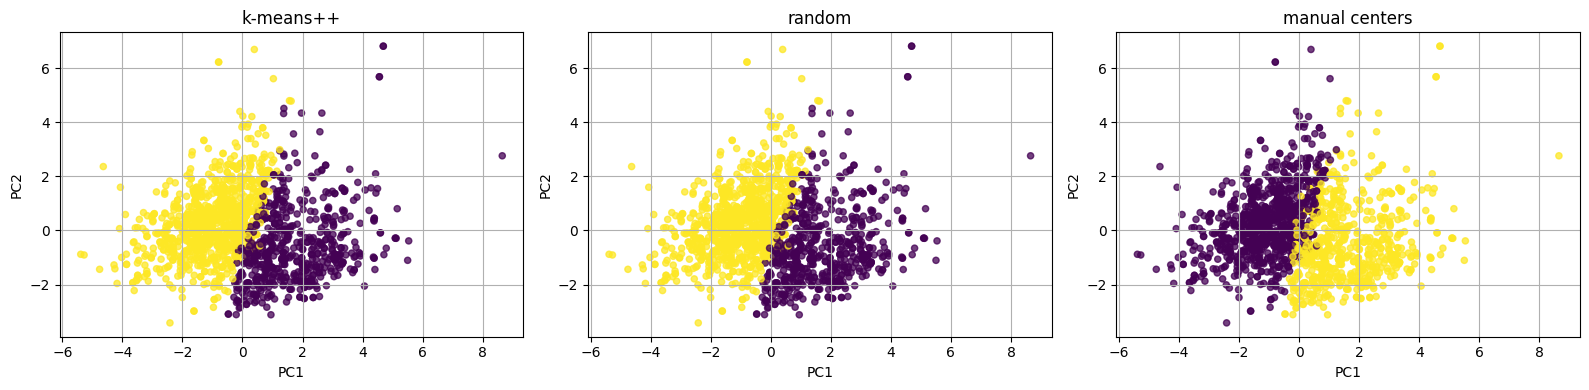

In [7]:
pca = PCA(n_components=2, random_state=SEED)
X_wine_pca = pca.fit_transform(X_wine_scaled)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, labels) in zip(axes, wine_labels.items()):
    ax.scatter(X_wine_pca[:, 0], X_wine_pca[:, 1], c=labels, cmap='viridis', s=20, alpha=0.75)
    ax.set_title(name)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.grid(True)
plt.tight_layout()
plt.show()

In [8]:
best_name = wine_results_df.sort_values('ARI', ascending=False).iloc[0]['Инициализация']
best_labels = wine_labels[best_name]

print('Лучший вариант по ARI:', best_name)
print('Матрица соответствия истинных классов и кластеров:')
print(confusion_matrix(y_wine, best_labels))

Лучший вариант по ARI: random
Матрица соответствия истинных классов и кластеров:
[[447 935]
 [141  76]]


# 2. Сжатие изображений методом KMeans

Для сжатия изображения каждый пиксель рассматривается как объект. Для черно-белого изображения объект имеет один признак — интенсивность. Для цветного изображения объект имеет три признака — значения каналов RGB.

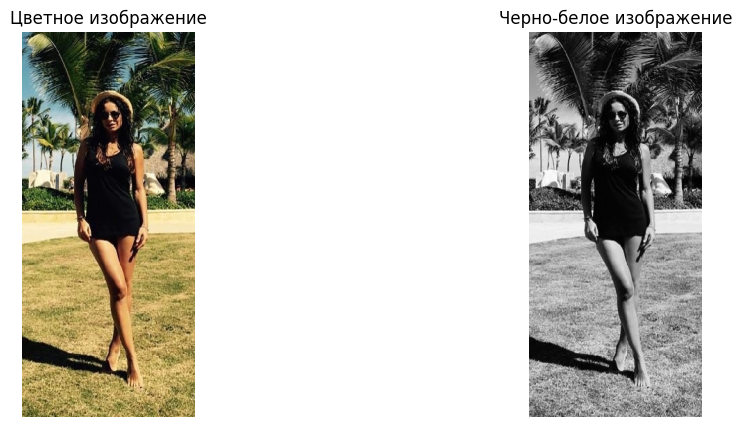

In [9]:
img_path = Path('source/Практика 11-12/img/woman.jpg')
color_img = mpimg.imread(img_path)

# Если изображение прочиталось в диапазоне 0..255, приведем его к 0..1
if color_img.max() > 1:
    color_img = color_img / 255.0

gray_img = np.dot(color_img[..., :3], [0.299, 0.587, 0.114])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(color_img)
axes[0].set_title('Цветное изображение')
axes[0].axis('off')
axes[1].imshow(gray_img, cmap='gray')
axes[1].set_title('Черно-белое изображение')
axes[1].axis('off')
plt.show()

In [10]:
def compress_grayscale(img, n_colors=4):
    h, w = img.shape
    pixels = img.reshape(-1, 1)
    km = KMeans(n_clusters=n_colors, random_state=SEED, n_init=5)
    labels = km.fit_predict(pixels)
    compressed = km.cluster_centers_[labels].reshape(h, w)
    return np.clip(compressed, 0, 1)

def compress_color(img, n_colors=16):
    h, w, c = img.shape
    pixels = img.reshape(-1, c)
    km = KMeans(n_clusters=n_colors, random_state=SEED, n_init=3)
    labels = km.fit_predict(pixels)
    compressed = km.cluster_centers_[labels].reshape(h, w, c)
    return np.clip(compressed, 0, 1)

gray_compressed = compress_grayscale(gray_img, n_colors=4)
color_compressed = compress_color(color_img, n_colors=16)

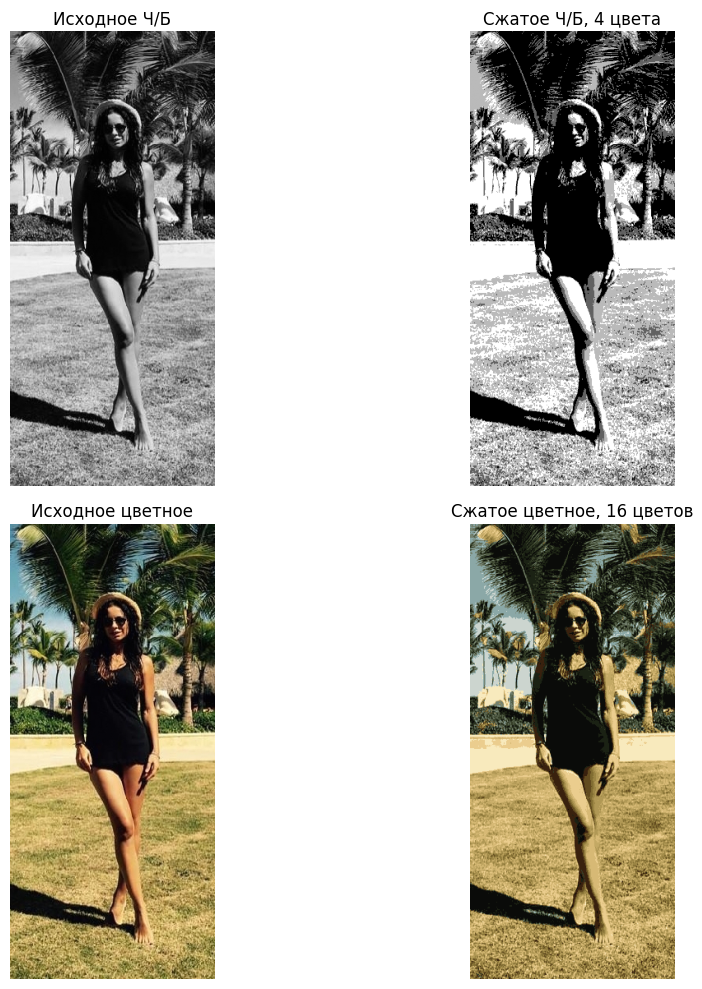

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(gray_img, cmap='gray')
axes[0, 0].set_title('Исходное Ч/Б')
axes[0, 0].axis('off')

axes[0, 1].imshow(gray_compressed, cmap='gray')
axes[0, 1].set_title('Сжатое Ч/Б, 4 цвета')
axes[0, 1].axis('off')

axes[1, 0].imshow(color_img)
axes[1, 0].set_title('Исходное цветное')
axes[1, 0].axis('off')

axes[1, 1].imshow(color_compressed)
axes[1, 1].set_title('Сжатое цветное, 16 цветов')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [12]:
plt.imsave('compressed_gray_kmeans.png', gray_compressed, cmap='gray')
plt.imsave('compressed_color_kmeans.png', color_compressed)
print('Сохранено: compressed_gray_kmeans.png')
print('Сохранено: compressed_color_kmeans.png')

Сохранено: compressed_gray_kmeans.png
Сохранено: compressed_color_kmeans.png


# 3. Кластеризация текстов 20 Newsgroups

Архив `KMeans.zip` сохранен в папке `source`. В нем находится каталог `20_newsgroups` с 20 тематическими подкаталогами. Прочитаем тексты прямо из архива и применим `KMeans` на 20 кластеров.

In [13]:
zip_path = Path('source/KMeans.zip')
texts = []
labels_text = []
target_names = []

with zipfile.ZipFile(zip_path) as z:
    file_names = [name for name in z.namelist() if name.startswith('20_newsgroups/') and not name.endswith('/')]
    categories = sorted({name.split('/')[1] for name in file_names if len(name.split('/')) > 2})
    category_to_id = {cat: i for i, cat in enumerate(categories)}
    target_names = categories

    for name in file_names:
        parts = name.split('/')
        if len(parts) < 3 or parts[1] not in category_to_id:
            continue
        try:
            text = z.read(name).decode('latin1', errors='ignore')
        except Exception:
            continue
        texts.append(text)
        labels_text.append(category_to_id[parts[1]])

labels_text = np.array(labels_text)
print('Количество документов:', len(texts))
print('Количество категорий:', len(target_names))
print(target_names[:5])

Количество документов: 19997
Количество категорий: 20
['alt.atheism', 'comp.graphics', 'comp.os.ms-windows.misc', 'comp.sys.ibm.pc.hardware', 'comp.sys.mac.hardware']


Преобразуем тексты в TF-IDF признаки. Чтобы вычисления были быстрее и устойчивее, ограничим словарь наиболее информативными словами.

In [14]:
vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=2,
    max_features=5000,
    stop_words='english'
)
X_text = vectorizer.fit_transform(texts)
print('Матрица TF-IDF:', X_text.shape)

Матрица TF-IDF: (19997, 5000)


In [15]:
text_kmeans = KMeans(n_clusters=20, init='k-means++', n_init=5, max_iter=100, random_state=SEED)
text_clusters = text_kmeans.fit_predict(X_text)

text_metrics = {
    'Homogeneity': homogeneity_score(labels_text, text_clusters),
    'Completeness': completeness_score(labels_text, text_clusters),
    'V-measure': v_measure_score(labels_text, text_clusters),
    'Adjusted Rand Index': adjusted_rand_score(labels_text, text_clusters),
    'Adjusted Mutual Info': adjusted_mutual_info_score(labels_text, text_clusters),
    'Silhouette': silhouette_score(X_text, text_clusters, sample_size=2000, random_state=SEED)
}

pd.DataFrame([text_metrics])

,Homogeneity,Completeness,V-measure,Adjusted Rand Index,Adjusted Mutual Info,Silhouette
0,0.367543,0.482756,0.417344,0.159139,0.415318,0.024184


In [16]:
terms = vectorizer.get_feature_names_out()
order_centroids = text_kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(20):
    top_words = ', '.join(terms[ind] for ind in order_centroids[i, :10])
    print(f'Cluster {i}: {top_words}')

Cluster 0: rutgers, christian, athos, geneva, god, religion, soc, igor, hedrick, aramis
Cluster 1: purdue, ecn, mentor, noose, cc, misc, engineering, university, talk, network
Cluster 2: uk, ac, uknet, demon, pipex, nz, comp, dcs, cam, za
Cluster 3: ca, bnr, ubc, bc, hockey, canada, uwaterloo, rec, carleton, sfu
Cluster 4: apple, sandvik, kent, newton, gallant, religion, talk, royalroads, misc, private
Cluster 5: mit, enterpoop, athena, lcs, internet, bedfellow, senator, expo, xpert, ai
Cluster 6: windows, os, ms, comp, misc, dos, apps, file, microsoft, motif
Cluster 7: talk, politics, misc, alt, guns, state, people, religion, ohio, israel
Cluster 8: space, sci, nasa, gov, digex, access, henry, astro, alaska, pitt
Cluster 9: au, oz, munnari, australia, monash, uwa, cc, comp, monu6, apana
Cluster 10: sys, ibm, comp, mac, hardware, pc, forsale, drive, scsi, state
Cluster 11: culture, soc, turkish, armenian, soviet, armenians, zuma, politics, mideast, armenia
Cluster 12: state, rec, ohio,

## Вывод

В практической работе был применен метод `KMeans` для трех задач.

1. Для датасета вин были проверены разные варианты инициализации центров. Результаты сравнивались с бинарной разметкой из третьей работы с помощью внешних метрик кластеризации (`ARI`, `AMI`, `homogeneity`, `completeness`, `V-measure`) и внутренней метрики `silhouette`. Так как кластеризация выполняется без учителя, совпадение с истинными классами не обязано быть идеальным.

2. Метод `KMeans` был использован для сжатия черно-белого и цветного изображения. Сжатие достигается за счет замены всех пикселей ближайшими центроидами: для черно-белого изображения оставлено 4 уровня яркости, для цветного — 16 цветов.

3. Для текстов `20_newsgroups` были построены TF-IDF признаки и выполнена кластеризация на 20 кластеров. Качество оценивалось сравнением найденных кластеров с исходными категориями датасета. Метрики показывают, насколько тематические группы совпали с кластерами, найденными без использования разметки.